In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import scipy.io
from mpl_toolkits.mplot3d import Axes3D
import gc

# 设置设备
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

使用设备: cuda:0


## `Material` 函数

### 参数
- `u_x, u_y, u_z, u_xx, u_xy, u_xz, u_yy, u_yz, u_zz`  
  位移分量 $u$ 在 $x,y,z$ 方向的一阶和二阶导数
- `v_x, v_y, v_z, v_xx, v_xy, v_xz, v_yy, v_yz, v_zz`  
  位移分量 $v$ 的各阶导数
- `w_x, w_y, w_z, w_xx, w_xy, w_xz, w_yy, w_yz, w_zz`  
  位移分量 $w$ 的各阶导数
- `E`：杨氏模量（默认为 `1.0`）  
- `mu`：泊松比 $\nu$（默认为 `0.25`）  
### 返回值
- **应变**  $ \varepsilon_{ij}  $
- **应力** $ \sigma_{ij} $
- **静力平衡残差** $ \bigl(\nabla\!\cdot\!\sigma\bigr)_i $  


In [4]:
def material(u_x, u_y, u_z, u_xx, u_xy, u_xz, u_yy, u_yz,u_zz,
            v_x, v_y, v_z, v_xx, v_xy, v_xz, v_yy, v_yz,v_zz,
            w_x, w_y, w_z, w_xx, w_xy, w_xz, w_yy, w_yz,w_zz, E=1.0, mu=0.25):
    """
    计算材料特性和应力
    
    参数:
        u_x, u_y, ... : 位移的一阶和二阶导数
        E: 杨氏模量
        mu: 泊松比
    
    返回:
        e1, e2, e3, e12, e23, e13: 应变
        s1, s2, s3, s12, s23, s13: 应力
        Gex, Gey, Gez: 平衡方程残差
    """

    # 计算拉梅常数
    la = E * mu / (1 + mu) / (1 - 2 * mu)
    G = E / (1 + mu) / 2

    # 计算应变
    e1 = u_x
    e2 = v_y
    e3 = w_z
    e12 = 0.5 * (u_y + v_x)
    e23 = 0.5 * (w_y + v_z)
    e13 = 0.5 * (u_z + w_x)

    # 计算应力
    s1 = (2 * G + la) * e1 + la * e2 + la * e3
    s2 = (2 * G + la) * e2 + la * e1 + la * e3
    s3 = (2 * G + la) * e3 + la * e1 + la * e2
    s12 = 2 * G * e12
    s23 = 2 * G * e23
    s13 = 2 * G * e13

    # 计算平衡方程残差
    Gex = (G + la) * (u_xx + v_xy + w_xz) + G * (u_xx + u_yy + u_zz)
    Gey = (G + la) * (v_yy + u_xy + w_yz) + G * (v_xx + v_yy + v_zz)
    Gez = (G + la) * (w_zz + u_xz + v_yz) + G * (w_xx + w_yy + w_zz)

    return e1, e2, e3, e12, e23, e13, s1, s2, s3, s12, s23, s13, Gex, Gey, Gez

## Class `MLP`

In [5]:
class MLP(nn.Module):
    """
    Multi-layer perceptron with tanh activation
    """
    def __init__(self, layers):
        super(MLP, self).__init__()
        
        modules = []
        for i in range(len(layers)-2):
            modules.append(nn.Linear(layers[i], layers[i+1]))
            modules.append(nn.Tanh())
        modules.append(nn.Linear(layers[-2], layers[-1]))
        
        self.net = nn.Sequential(*modules)
        
        # Initialize weights using Xavier/Glorot initialization
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        return self.net(x)


## Class `CustomDataset`

In [6]:
class CustomDataset(Dataset):
    def __init__(self, x, x1u, x1b, x2u, x2b, x3u, x3b,batch_size):
        """
        弹性力学问题的数据集
        
        参数:
            x: 内部点坐标
            x1u, x1b, x2u, x2b, x3u, x3b: 边界点坐标
        """
        self.x = torch.tensor(x, dtype=torch.float32).to(device)
        self.x1u = torch.tensor(x1u, dtype=torch.float32).to(device)
        self.x1b = torch.tensor(x1b, dtype=torch.float32).to(device)
        self.x2u = torch.tensor(x2u, dtype=torch.float32).to(device)
        self.x2b = torch.tensor(x2b, dtype=torch.float32).to(device)
        self.x3u = torch.tensor(x3u, dtype=torch.float32).to(device)
        self.x3b = torch.tensor(x3b, dtype=torch.float32).to(device)
        self.batch_size = batch_size

        # 计算目标值
        self.s3u1 = torch.cos(self.x3u[:, 0] / 2 * np.pi) * torch.cos(self.x3u[:, 1] / 2 * np.pi)
        self.s3u1 = self.s3u1.to(device)
        
        self.N = x.shape[0]
    def __len__(self):
        return self.N
    
    def __getitem__(self, idx):
        indices = torch.randperm(self.N, device=self.x.device)[:self.batch_size]
        x_batch = self.x[indices]
        y_batch = self.s3u1
        return x_batch, self.x1u, self.x1b, self.x2u, self.x2b, self.x3u, self.x3b,y_batch  

## `MultiFNN` 类概览
* 1. `__init__`: 构造函数
* 2. 分量预测方法：`u_model`, `v_model`, `w_model`
* 3. 自动微分：`compute_derivatives`
* 4. 前向传播与损失计
* 5. `predict` 方法
* 6. `predict_stress` 方法

In [7]:
class MultiFNN(nn.Module):
    """
    物理信息神经网络，包含三个子网络分别用于u, v, w分量
    """
    def __init__(self, layers):
        super(MultiFNN, self).__init__()
        
        # 为每个分量创建子网络
        self.u_net = MLP(layers).to(device)
        self.v_net = MLP(layers).to(device)
        self.w_net = MLP(layers).to(device)
        
        # 日志记录器
        self.loss_log = []
        self.loss_res_log = []
        self.loss_x_log = []
        self.loss_y_log = []
        self.loss_z_log = []
    
    def u_model(self, x, y, z):
        """u分量模型"""
        # 检查输入形状
        inputs = torch.stack([x, y, z], dim=-1)
        # 确保形状匹配避免广播
        output = self.u_net(inputs)
        output = output.squeeze(-1)
        return output * x
    
    def v_model(self, x, y, z):
        """v分量模型"""
        # 检查输入形状
        inputs = torch.stack([x, y, z], dim=-1)
        # 确保形状匹配避免广播
        output = self.v_net(inputs)
        output = output.squeeze(-1)
        return output * y
    
    def w_model(self, x, y, z):
        """w分量模型"""
        # 检查输入形状
        inputs = torch.stack([x, y, z], dim=-1)
        # 确保形状匹配避免广播
        output = self.w_net(inputs)
        output = output.squeeze(-1)
        return output * z  
    
    def compute_derivatives(self, x, y, z):
        """使用自动微分计算所需的导数"""
        # 使坐标需要梯度
        x.requires_grad_(True)
        y.requires_grad_(True)
        z.requires_grad_(True)

        # 前向传播
        u = self.u_model(x, y, z)
        v = self.v_model(x, y, z)
        w = self.w_model(x, y, z)
        
        # 一阶导数
        u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_y = torch.autograd.grad(u, y, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_z = torch.autograd.grad(u, z, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        
        v_x = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0]
        v_y = torch.autograd.grad(v, y, grad_outputs=torch.ones_like(v), create_graph=True)[0]
        v_z = torch.autograd.grad(v, z, grad_outputs=torch.ones_like(v), create_graph=True)[0]
        
        w_x = torch.autograd.grad(w, x, grad_outputs=torch.ones_like(w), create_graph=True)[0]
        w_y = torch.autograd.grad(w, y, grad_outputs=torch.ones_like(w), create_graph=True)[0]
        w_z = torch.autograd.grad(w, z, grad_outputs=torch.ones_like(w), create_graph=True)[0]
        
        # 二阶导数
        u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
        u_xy = torch.autograd.grad(u_x, y, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
        u_xz = torch.autograd.grad(u_x, z, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
        
        u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]
        u_yz = torch.autograd.grad(u_y, z, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]
        u_zz = torch.autograd.grad(u_z, z, grad_outputs=torch.ones_like(u_z), create_graph=True)[0]
        
        v_xx = torch.autograd.grad(v_x, x, grad_outputs=torch.ones_like(v_x), create_graph=True)[0]
        v_xy = torch.autograd.grad(v_x, y, grad_outputs=torch.ones_like(v_x), create_graph=True)[0]
        v_xz = torch.autograd.grad(v_x, z, grad_outputs=torch.ones_like(v_x), create_graph=True)[0]
        
        v_yy = torch.autograd.grad(v_y, y, grad_outputs=torch.ones_like(v_y), create_graph=True)[0]
        v_yz = torch.autograd.grad(v_y, z, grad_outputs=torch.ones_like(v_y), create_graph=True)[0]   
        v_zz = torch.autograd.grad(v_z, z, grad_outputs=torch.ones_like(v_z), create_graph=True)[0]
        
        w_xx = torch.autograd.grad(w_x, x, grad_outputs=torch.ones_like(w_x), create_graph=True)[0]
        w_xy = torch.autograd.grad(w_x, y, grad_outputs=torch.ones_like(w_x), create_graph=True)[0]
        w_xz = torch.autograd.grad(w_x, z, grad_outputs=torch.ones_like(w_x), create_graph=True)[0]
        
        w_yy = torch.autograd.grad(w_y, y, grad_outputs=torch.ones_like(w_y), create_graph=True)[0]
        w_yz = torch.autograd.grad(w_y, z, grad_outputs=torch.ones_like(w_y), create_graph=True)[0]   
        w_zz = torch.autograd.grad(w_z, z, grad_outputs=torch.ones_like(w_z), create_graph=True)[0]

        # 打印梯度

            
        return (u_x, u_y, u_z, u_xx, u_xy, u_xz, u_yy, u_yz, u_zz,
                v_x, v_y, v_z, v_xx, v_xy, v_xz, v_yy, v_yz, v_zz,
                w_x, w_y, w_z, w_xx, w_xy, w_xz, w_yy, w_yz, w_zz)
    
    def forward(self, batch):
        """前向传播计算损失分量"""
        x, x1u, x1b, x2u, x2b, x3u, x3b, y = batch
        # 内部域
        a, b, c = x[ :,0], x[ :,1], x[:,2]
        # 计算内部点的导数

        derivs = self.compute_derivatives(a, b, c)
    
        # 获取材料残差
        _, _, _, _, _, _, _, _, _, _, _, _, Gex, Gey, Gez = material(*derivs)

        
        # 计算边界导数 - x-y-z平面 Up/Bottom
        a1u, b1u, c1u = x1u[:, 0], x1u[ :,1], x1u[:, 2]
        a1b, b1b, c1b = x1b[:, 0], x1b[ :,1], x1b[:, 2]
        a2u, b2u, c2u = x2u[:, 0], x2u[:, 1], x2u[:, 2]
        a2b, b2b, c2b = x2b[:, 0], x2b[:, 1], x2b[:,2]
        a3u, b3u, c3u = x3u[:, 0], x3u[:, 1], x3u[:,2]
        a3b, b3b, c3b = x3b[ :,0], x3b[ :,1], x3b[:,2]
        
        # 计算边界点的导数
        derivs_1u = self.compute_derivatives(a1u, b1u, c1u)
        derivs_1b = self.compute_derivatives(a1b, b1b, c1b)
        derivs_2u = self.compute_derivatives(a2u, b2u, c2u)
        derivs_2b = self.compute_derivatives(a2b, b2b, c2b)
        derivs_3u = self.compute_derivatives(a3u, b3u, c3u)
        derivs_3b = self.compute_derivatives(a3b, b3b, c3b)
        
        # 获取每个边界的材料特性
        _, _, _, _, _, _, s11u, _, _, s121u, _, s131u, _, _, _ = material(*derivs_1u)
        _, _, _, _, _, _, _, _, _, s121b, _, s131b, _, _, _ = material(*derivs_1b)
        _, _, _, _, _, _, _, s22u, _, s122u, s232u, _, _, _, _ = material(*derivs_2u)
        _, _, _, _, _, _, _, _, _, s122b, s232b, _, _, _, _ = material(*derivs_2b)
        _, _, _, _, _, _, _, _, s33u, _, s233u, s133u, _, _, _ = material(*derivs_3u)
        _, _, _, _, _, _, _, _, _, _, s233b, s133b, _, _, _ = material(*derivs_3b)
        # 计算损失
        l1 = torch.sum(Gex**2) + torch.sum(Gey**2) + torch.sum(Gez**2)
        
        lx = (torch.sum(s11u**2) + torch.sum(s121u**2) + torch.sum(s131u**2) + 
              torch.sum(s121b**2) + torch.sum(s131b**2))
        
        ly = (torch.sum(s22u**2) + torch.sum(s122u**2) + torch.sum(s232u**2) + 
              torch.sum(s122b**2) + torch.sum(s232b**2))
        
        lz = (torch.sum((s33u-y)**2) + torch.sum(s233u**2) + torch.sum(s133u**2) + 
              torch.sum(s233b**2) + torch.sum(s133b**2))
        
        l2 = lx + ly + lz
        
        # 总损失
        loss = l1 + l2
        
        return l1, lx, ly, lz, loss
    
    
    def predict(self, x_coords, batch_size=9261):
        n_samples = x_coords.shape[0]
        u_result = np.zeros(n_samples)
        v_result = np.zeros(n_samples)
        w_result = np.zeros(n_samples)
        bs = int(batch_size)
        for i in range(0, n_samples, bs):
            end = min(i + bs, n_samples)
            x_batch = x_coords[i:end]
            x = torch.tensor(x_batch[:, 0], dtype=torch.float32).to(device)
            y = torch.tensor(x_batch[:, 1], dtype=torch.float32).to(device)
            z = torch.tensor(x_batch[:, 2], dtype=torch.float32).to(device)

            with torch.no_grad():
                u = self.u_model(x, y, z)
                v = self.v_model(x, y, z)
                w = self.w_model(x, y, z)


                assert u.shape[0] == (end - i)
                assert v.shape[0] == (end - i)
                assert w.shape[0] == (end - i)

                u_result[i:end] = u.cpu().numpy()
                v_result[i:end] = v.cpu().numpy()
                w_result[i:end] = w.cpu().numpy()

            del u, v, w, x, y, z

        return u_result, v_result, w_result


    def predict_stress(self, x_coords, batch_size=9261):
        """使用批处理方式预测应力，避免内存溢出"""

        num_points = x_coords.shape[0]
        # 计算需要的批次数量
        num_batches = (num_points + batch_size - 1) // batch_size

        # 预先分配存储结果的 NumPy 数组
        # 假设应变和应力是单个浮点数值，形状与输入点数相同
        # 如果它们是张量或有其他维度，请调整 shape
        e1_results = np.empty(num_points, dtype=np.float32)
        e2_results = np.empty(num_points, dtype=np.float32)
        e3_results = np.empty(num_points, dtype=np.float32)
        e12_results = np.empty(num_points, dtype=np.float32)
        e23_results = np.empty(num_points, dtype=np.float32)
        e13_results = np.empty(num_points, dtype=np.float32)
        s1_results = np.empty(num_points, dtype=np.float32)
        s2_results = np.empty(num_points, dtype=np.float32)
        s3_results = np.empty(num_points, dtype=np.float32)
        s12_results = np.empty(num_points, dtype=np.float32)
        s23_results = np.empty(num_points, dtype=np.float32)
        s13_results = np.empty(num_points, dtype=np.float32)
        gx_results = np.empty(num_points, dtype=np.float32)
        gy_results = np.empty(num_points, dtype=np.float32)
        gz_results = np.empty(num_points, dtype=np.float32)


        # 循环处理每个批次
        for i in range(num_batches):
            # 计算当前批次的起始和结束索引
            start_idx = i * batch_size
            end_idx = min((i + 1) * batch_size, num_points)

            # 提取当前批次的坐标
            x_batch = x_coords[start_idx:end_idx, :]

            # 将当前批次转换为 Tensor 并移动到设备
            # 确保这里只处理 batch_size 个点，而不是整个数据集
            x = torch.tensor(x_batch[:, 0], dtype=torch.float32).to(device)
            y = torch.tensor(x_batch[:, 1], dtype=torch.float32).to(device)
            z = torch.tensor(x_batch[:, 2], dtype=torch.float32).to(device)

            # 计算当前批次的导数
            # derivs 中的张量大小是 [当前批次大小, ...]
            derivs = self.compute_derivatives(x, y, z)
            # 计算当前批次的应变/应力/残差
            # e, s, g 中的张量大小是 [当前批次大小, ...]
            
            e1, e2, e3, e12, e23, e13, s1, s2, s3, s12, s23, s13, gx, gy, gz = material(*derivs)
            # 将当前批次的结果转换为 NumPy 数组并存储到预分配的总结果数组中
            # 这里只处理并存储一个批次的结果
            e1_results[start_idx:end_idx] = e1.detach().cpu().numpy().flatten() # .flatten() 如果结果是单值
            e2_results[start_idx:end_idx] = e2.detach().cpu().numpy().flatten()
            e3_results[start_idx:end_idx] = e3.detach().cpu().numpy().flatten()
            e12_results[start_idx:end_idx] = e12.detach().cpu().numpy().flatten()
            e23_results[start_idx:end_idx] = e23.detach().cpu().numpy().flatten()
            e13_results[start_idx:end_idx] = e13.detach().cpu().numpy().flatten()
            s1_results[start_idx:end_idx] = s1.detach().cpu().numpy().flatten()
            s2_results[start_idx:end_idx] = s2.detach().cpu().numpy().flatten()
            s3_results[start_idx:end_idx] = s3.detach().cpu().numpy().flatten()
            s12_results[start_idx:end_idx] = s12.detach().cpu().numpy().flatten()
            s23_results[start_idx:end_idx] = s23.detach().cpu().numpy().flatten()
            s13_results[start_idx:end_idx] = s13.detach().cpu().numpy().flatten()
            gx_results[start_idx:end_idx] = gx.detach().cpu().numpy().flatten()
            gy_results[start_idx:end_idx] = gy.detach().cpu().numpy().flatten()
            gz_results[start_idx:end_idx] = gz.detach().cpu().numpy().flatten()

            # 释放当前批次不再需要的内存
            # (PyTorch/TensorFlow 的垃圾回收通常会自动处理，但显式删除有时有帮助)
            del x, y, z, derivs, e1, e2, e3, e12, e23, e13, s1, s2, s3, s12, s23, s13, gx, gy, gz
            torch.cuda.empty_cache() # 如果使用 CUDA

        # 返回累积了所有批次结果的 NumPy 数组
        return (e1_results, e2_results, e3_results, e12_results, e23_results, e13_results,
                s1_results, s2_results, s3_results, s12_results, s23_results, s13_results,
                gx_results, gy_results, gz_results)

## 加载数据

In [8]:
# 加载训练数据
def load_data(file_path='./data/Coord.mat'):
    print("加载训练数据...")
    # 加载数据
    C = scipy.io.loadmat(file_path)
    x = C['xy']
    x1u = C['x1u']
    x1b = C['x1b']
    x2u = C['x2u']
    x2b = C['x2b']
    x3u = C['x3u']
    x3b = C['x3b']
    ns = C['n'][0, 0]
    batch_size = ns
    # 创建数据集
    dataset = CustomDataset(x, x1u, x1b, x2u, x2b, x3u, x3b,batch_size)
    return dataset

# 加载测试数据
def load_test_data(file_path='./data/FEA.mat'):
    print("加载测试数据...")
    # 加载测试数据
    test_data = scipy.io.loadmat(file_path)
    test_x = np.array(test_data['X'])
    print(f"测试数据大小: {test_x.shape}")
    return test_x


## train_model 函数

In [ ]:
def train_model(model, dataset, n_iter=10000, lr=1e-2):
    """
    训练 PINN 模型（仅替换此函数，其他部分保持不变）
    
    model(batch) -> 返回 (l_pde, l_xbc, l_ybc, l_zbc, preds…)
    """
    # 超参（可根据需要再调）
    clip_max_norm = 5.0            # 梯度裁剪阈值
    update_every = 100             # 隔多少步刷新一次内部点


    # Optimizer & 动态 LR 调度
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.8, patience=2000, verbose=True
    )

    # 清空日志
    model.loss_log      = []
    model.loss_res_log  = []
    model.loss_x_log    = []
    model.loss_y_log    = []
    model.loss_z_log    = []

    # 首次取一批数据（内部 + 边界 + 真值）
    batch = dataset[0]

    pbar = tqdm(range(n_iter))
    for it in pbar:
        # 定期刷新内部点采样
        if it % update_every == 0:
            batch = dataset[0]
        #x_coll, x1u, x1b, x2u, x2b, x3u, x3b, y_true = batch

        # 前向：各项损失
        l_pde, l_x, l_y, l_z, _ = model(batch)
        l_bc  = l_x + l_y + l_z
        loss  = l_pde + l_bc

        # 反向 & 梯度裁剪
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_max_norm)
        optimizer.step()

        # 根据 loss 自动调整 lr
        scheduler.step(loss)

        # 记录损失
        if it % 10 == 0:
            model.loss_log.append(loss.item())
            model.loss_res_log.append(l_pde.item())  
            model.loss_x_log.append(l_x.item())
            model.loss_y_log.append(l_y.item())
            model.loss_z_log.append(l_z.item())

        # 更新进度
        if it % 10 == 0:
            pbar.set_postfix({
                'Loss': f"{loss.item():.2f}",
                'PDE': f"{l_pde.item():.2e}",
                'BC': f"{l_bc.item():.2e}",
                'lx': f"{l_x.item():.2f}",
                'ly': f"{l_y.item():.2f}",
                'lz': f"{l_z.item():.2f}",
                'LR':   f"{optimizer.param_groups[0]['lr']:.2e}"
            })

    return model


## 模型的保存与下载

In [12]:
def save_model(model, filepath='./model/pinn_elasticity_model.pt'):
    """
    模型参数和训练日志
    """
    log_dict = {
        'loss_total':    model.loss_log,
        'loss_pde':      model.loss_res_log,
        'loss_x_bnd':    model.loss_x_log,
        'loss_y_bnd':    model.loss_y_log,
        'loss_z_bnd':    model.loss_z_log
    }

    checkpoint = {
        'model_state': model.state_dict(),
        'logs':        log_dict
    }

    torch.save(checkpoint, filepath)
    print(f"✅ 模型和日志已保存到 {filepath}")
    
    
def load_model(model, filepath='./model/pinn_elasticity_model.pt', device='cpu'):
    """
    从 checkpoint 中加载模型参数及训练日志（按 logs 字段组织）。
    """
    ckpt = torch.load(filepath, map_location=device)
    
    # 恢复模型参数
    model.load_state_dict(ckpt['model_state'])
    model.to(device)
    
    # 恢复日志
    logs = ckpt.get('logs', {})
    model.loss_log      = logs.get('loss_total', [])
    model.loss_res_log  = logs.get('loss_pde', [])
    model.loss_x_log    = logs.get('loss_x_bnd', [])
    model.loss_y_log    = logs.get('loss_y_bnd', [])
    model.loss_z_log    = logs.get('loss_z_bnd', [])
    
    print(f"✅ 已从 {filepath} 加载模型参数和训练日志")
    return model


## 模型评估
 - 物理损失评估
 - 损失函数

In [13]:
def evaluate_physics_metrics(model):
    """
    从训练时记录的日志中，直接汇总各物理残差的平均值。
    """
    avg_total = np.mean(model.loss_log)
    avg_pde   = np.mean(model.loss_res_log)
    avg_lx    = np.mean(model.loss_x_log)
    avg_ly    = np.mean(model.loss_y_log)
    avg_lz    = np.mean(model.loss_z_log)

    print(" 训练日志物理评估：")
    print(f"  平均总损失   : {avg_total:.3f}")
    print(f"  平均 PDE 残差: {avg_pde:.3f}")
    print(f"  平均边界残差 lx: {avg_lx:.3f}")
    print(f"  平均边界残差 ly: {avg_ly:.3f}")
    print(f"  平均边界残差 lz: {avg_lz:.3f}")


    return {
        'avg_total': avg_total,
        'avg_pde':   avg_pde,
        'avg_lx':    avg_lx,
        'avg_ly':    avg_ly,
        'avg_lz':    avg_lz,
    }

In [14]:
def loss_curve(model,filepath='./viz/loss_curve.png'):
    """
    在同一张图中绘制总损失 (loss) 和各物理残差 (l1, lx, ly, lz) 的收敛曲线
    """

    plt.figure(figsize=(10, 6))
    # Plot all loss curves
    plt.plot(model.loss_log,      linewidth=2, label='Total Loss')
    plt.plot(model.loss_res_log,  linewidth=2, label='PDE Residual (l1)')
    plt.plot(model.loss_x_log,    linewidth=2, label='Boundary Residual lx')
    plt.plot(model.loss_y_log,    linewidth=2, label='Boundary Residual ly')
    plt.plot(model.loss_z_log,    linewidth=2, label='Boundary Residual lz')

    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('Loss Value', fontsize=12)
    plt.title('Training Loss and Physics Residuals Over Iterations', fontsize=14, fontweight='bold')
    plt.yscale('log')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend(loc='upper right')
    plt.tight_layout()
    
    # Save the figure
    plt.savefig(filepath, dpi=300)
    plt.show()


## 可视化

In [15]:
def plot_displacement(test_x,model, batch_size=9261,save_path='./viz/predict_displacement.png'):
    """
    对一组三维坐标批量预测并在 1×3 子图中绘制位移云图（u, v, w）
    """
    u, v, w = model.predict(test_x, batch_size=batch_size)
    titles = ['U Displacement', 'V Displacement', 'W Displacement']
    values = [u, v, w]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={'projection': '3d'})
    fig.suptitle('Displacement Prediction', fontsize=20, fontweight='bold', y=1.02)
    for ax, vc, title in zip(axes, values, titles):
        vmax, vmin = np.max(vc), np.min(vc)
        im = ax.scatter(test_x[:,1], test_x[:,0], test_x[:,2],
                        c=vc, cmap='jet', vmin=vmin, vmax=vmax)
        ax.set_title(title, fontsize=14)
        ax.set_xlabel('y'); ax.set_ylabel('x'); ax.set_zlabel('z')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
     # 保存图像
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


In [16]:
def plot_stress(test_x, model, batch_size=9261,save_path='./viz/predict_stress.png'):
    """
    对一组三维坐标批量预测并在 2×3 子图中绘制应力云图
    """
    # predict_stress 返回 (e1,e2,e3,e12,e23,e13,s1,s2,s3,s12,s23,s13,gx,gy,gz)
    *_, s1, s2, s3, s12, s23, s13, _, _, _ = model.predict_stress(test_x, batch_size=batch_size)
    titles = ['S1 Stress', 'S2 Stress', 'S3 Stress', 'S12 Stress', 'S23 Stress', 'S13 Stress']
    values = [s1, s2, s3, s12, s23, s13]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10), subplot_kw={'projection': '3d'})
    fig.suptitle('Stress Prediction', fontsize=20, fontweight='bold', y=1.02)
    for ax, vc, title in zip(axes.flat, values, titles):
        vmax, vmin = np.max(vc), np.min(vc)
        im = ax.scatter(test_x[:,1], test_x[:,0], test_x[:,2],
                        c=vc, cmap='jet', vmin=vmin, vmax=vmax)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('y'); ax.set_ylabel('x'); ax.set_zlabel('z')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    # 保存图像
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

加载训练数据...
初始化模型...


加载已有模型...
✅ 已从 ./model/pinn_elasticity_model.pt 加载模型参数和训练日志
加载测试数据...
测试数据大小: (522801, 3)
开始预测...


/tmp/ipykernel_3148933/2580371627.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(filepath, map_location=device)


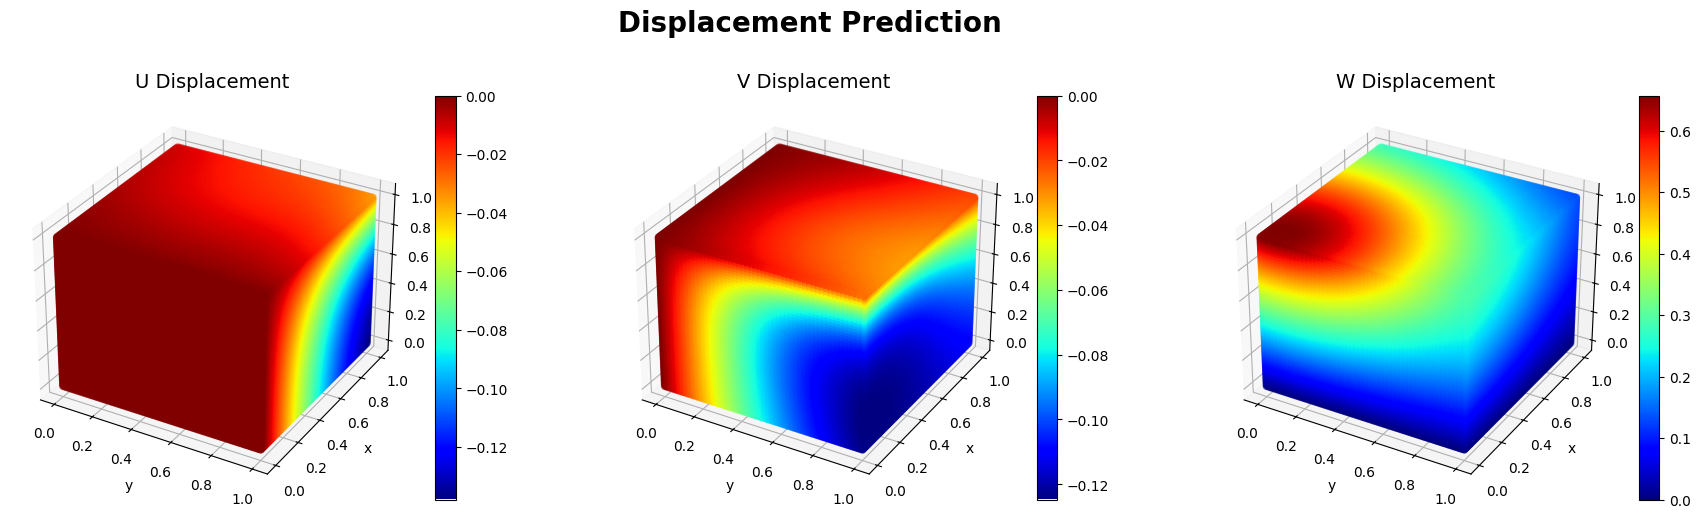

计算应力...


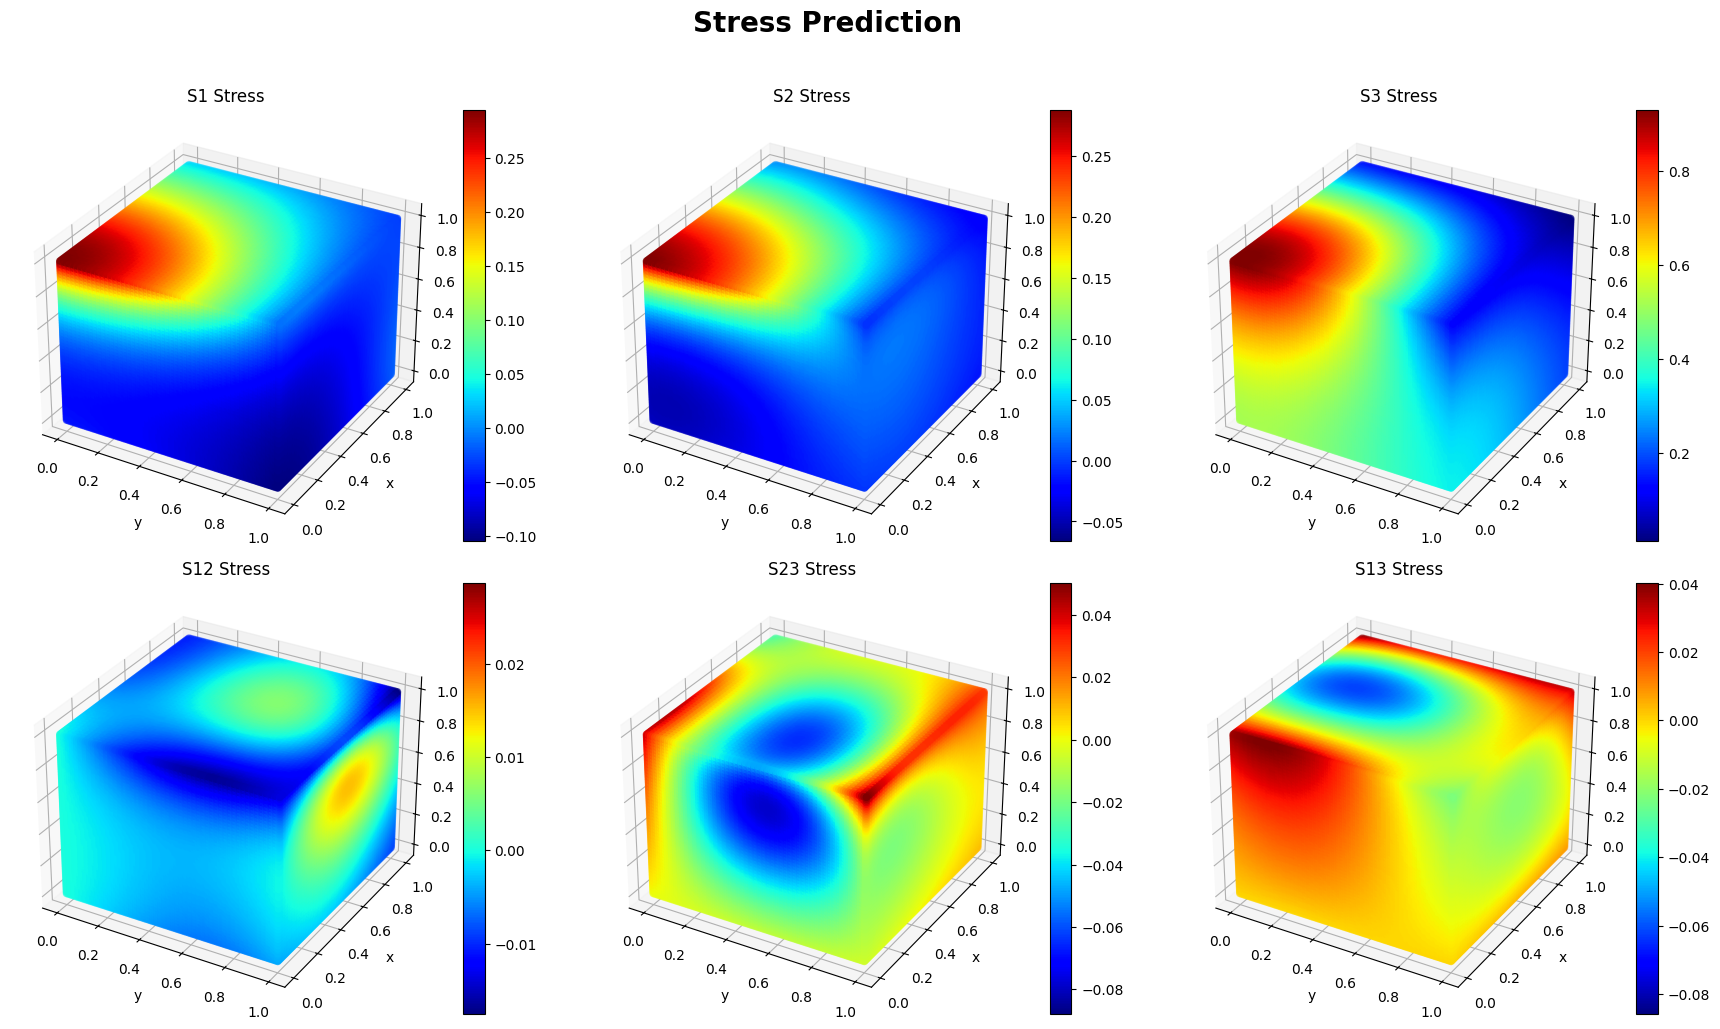

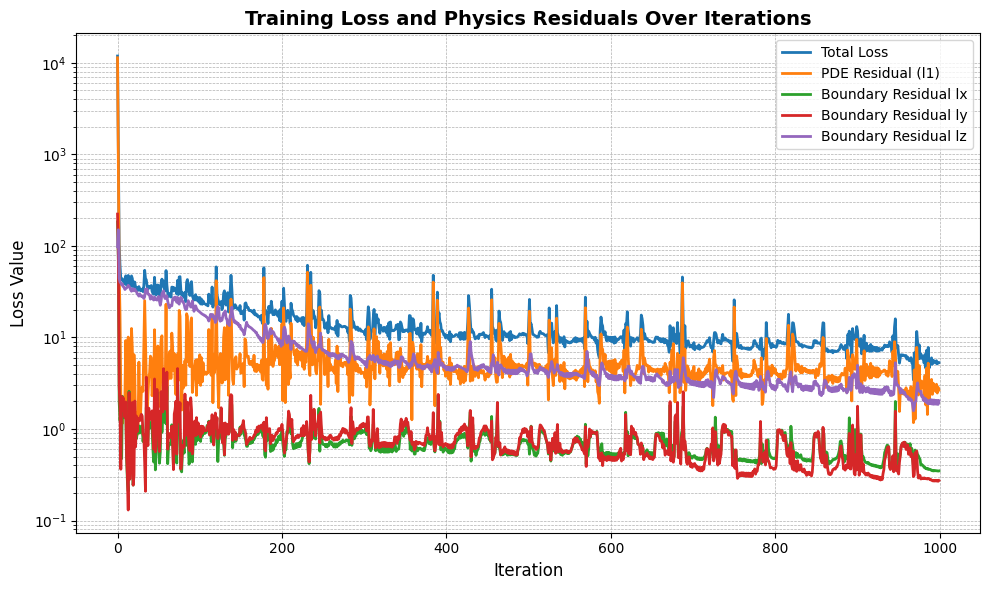

 训练日志物理评估：
  平均总损失   : 27.398
  平均 PDE 残差: 17.562
  平均边界残差 lx: 0.974
  平均边界残差 ly: 1.065
  平均边界残差 lz: 7.797


In [18]:
def run():
    """主函数：加载数据、训练模型并可视化结果"""
    # 加载数据
    dataset = load_data()
    
    # 初始化模型
    print("初始化模型...")
    layers = [3, 20, 20, 20, 20, 1]
    model = MultiFNN(layers).to(device)

    # 询问是否训练模型
    train_flag = input("是否训练模型? (y/n): ").lower()
    if train_flag == 'y':
        print("开始训练模型...")
        # 训练模型
        train_model(model, dataset)
        # 询问是否保存模型
        save_flag = input("是否保存模型? (y/n): ").lower()
        if save_flag == 'y':
            save_model(model, './model/pinn_elasticity_model.pt')
    elif train_flag == 'n':
        print("加载已有模型...")
        # 询问是否加载已有模型
        load_model(model, './model/pinn_elasticity_model.pt', device=device)
    else:
        print("退出程序")
        return
    
    # 加载测试数据
    test_x = load_test_data()
    print("开始预测...")
    # 预测位移
    plot_displacement(test_x, model, batch_size=dataset.batch_size)
    # 计算应力
    print("计算应力...")
    plot_stress(test_x, model, batch_size=dataset.batch_size)
    #绘制损失曲线
    loss_curve(model)
    #物理损失
    evaluate_physics_metrics(model)
# 执行主函数
if __name__ == "__main__":
    run()
